# 3. Model Train

### Baseline Model: Linear Regression
- First lets try Linear Regression to understand problem is linear or not.

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r'..\data\processed\processed_data.csv')

In [3]:
df.head()

,engine_id,cycle,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,...,sensor_17_roll_mean,sensor_17_roll_std,sensor_18_roll_mean,sensor_18_roll_std,sensor_19_roll_mean,sensor_19_roll_std,sensor_20_roll_mean,sensor_20_roll_std,sensor_21_roll_mean,sensor_21_roll_std
0,1,1,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,...,392.000000,0.000000,2388.0,0.0,100.0,0.0,39.060000,0.000000,23.419000,0.000000
1,1,2,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,...,392.000000,0.000000,2388.0,0.0,100.0,0.0,39.030000,0.042426,23.421300,0.003253
2,1,3,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,...,391.333333,1.154701,2388.0,0.0,100.0,0.0,39.003333,0.055076,23.395600,0.044573
3,1,4,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,...,391.500000,1.000000,2388.0,0.0,100.0,0.0,38.972500,0.076322,23.390175,0.037977
4,1,5,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,...,391.800000,1.095445,2388.0,0.0,100.0,0.0,38.958000,0.073621,23.393020,0.033498


In [4]:
df.columns

Index(['engine_id', 'cycle', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4',
       'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
       'sensor_21', 'RUL', 'sensor_1_roll_mean', 'sensor_1_roll_std',
       'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_3_roll_mean',
       'sensor_3_roll_std', 'sensor_4_roll_mean', 'sensor_4_roll_std',
       'sensor_5_roll_mean', 'sensor_5_roll_std', 'sensor_6_roll_mean',
       'sensor_6_roll_std', 'sensor_7_roll_mean', 'sensor_7_roll_std',
       'sensor_8_roll_mean', 'sensor_8_roll_std', 'sensor_9_roll_mean',
       'sensor_9_roll_std', 'sensor_10_roll_mean', 'sensor_10_roll_std',
       'sensor_11_roll_mean', 'sensor_11_roll_std', 'sensor_12_roll_mean',
       'sensor_12_roll_std', 'sensor_13_roll_mean', 'sensor_13_roll_std',
       'sensor_14_roll_mean', 'sensor_14_roll_std

In [5]:
X = df.drop('RUL', axis=1)
y = df["RUL"]

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state=42)

In [7]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [8]:
y_pred = lr.predict(X_test)

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [11]:
print(f' mean absolute error: {mae}')
print(f' Root mean square error: {rmse}')
print(f' R2 score: {r2}')

 mean absolute error: 29.44201798362441
 Root mean square error: 38.168650951064684
 R2 score: 0.6811312664127149


### Random Forest Model 

In [12]:
from sklearn.ensemble import RandomForestRegressor

In [13]:
rf = RandomForestRegressor( n_estimators =100, max_depth=None, min_samples_split=2,
                           min_samples_leaf = 1, random_state=42, n_jobs=-1)

In [14]:
model_train =rf.fit(X_train, y_train)
model_train

RandomForestRegressor(n_jobs=-1, random_state=42)

In [15]:
y_pred_rf = rf.predict(X_test)

In [16]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [17]:
print('Result evaluation of Random Forest Regressor')
print(f' mean absolute error: {mae_rf}')
print(f' Root mean square error: {rmse_rf}')
print(f' R2 score: {r2_rf}')

Result evaluation of Random Forest Regressor
 mean absolute error: 4.998509813423795
 Root mean square error: 8.234052526429263
 R2 score: 0.9851602842417124


In [21]:
import joblib

FEATURE_COLUMNS = X_train.columns.tolist()

joblib.dump(FEATURE_COLUMNS, "../app/model/feature_columns.pkl")
joblib.dump(model_train, "../app/model/random_forest_rul.pkl")


['../app/model/random_forest_rul.pkl']

### Prediction vs Actual 

In [22]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Random Forest: Actual vs Predicted RUL')

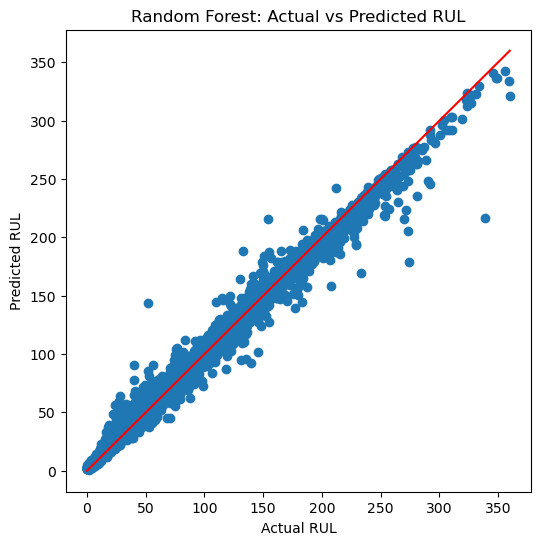

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)  # x-axis is actual value, y-axis as predicted value(random forest regressor)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red') # assuming both axis as y_test
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Random Forest: Actual vs Predicted RUL")

A Random Forest regressor is trained to capture non-linear degradation patterns in engine sensor data. The model significantly outperforms the linear baseline, demonstrating the effectiveness of rolling-window temporal features.

### Model Interpretation

In [24]:
# extract feature importances

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_}).sort_values(by="importance", ascending=False)

In [25]:
feature_importance.head(15)

,feature,importance
1,cycle,0.526026
27,sensor_3_roll_mean,0.105980
0,engine_id,0.096578
51,sensor_15_roll_mean,0.037929
25,sensor_2_roll_mean,0.032657
49,sensor_14_roll_mean,0.023308
39,sensor_9_roll_mean,0.018855
35,sensor_7_roll_mean,0.014570
45,sensor_12_roll_mean,0.012735
47,sensor_13_roll_mean,0.010606


Text(0.5, 1.0, 'Top 20 Feature Importances (Random Forest section)')

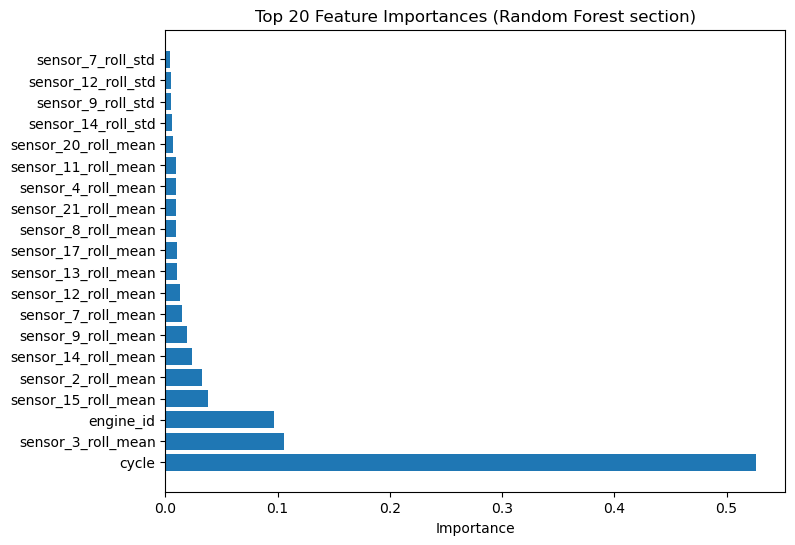

In [26]:
top_features = feature_importance.head(20)

plt.figure(figsize=(8,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (Random Forest section)")

Random Forest feature importance reveals that rolling mean and standard deviation features contribute most to RUL prediction. This aligns with the intuition that engine degradation is driven by temporal trends rather than single-cycle sensor values.